# Replica Parameter Uncertainty

Summary notebook for the current `../Fits/replica_refits.csv` schema.
It maps `param_i` columns back to the active card parameter names and reports
robust central intervals for the stored replica refits.


In [1]:
import csv
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")


In [2]:
fit_name = "BroadBump42LogGaussAlpha1NoLambda2"
replica_results_path = Path("../Fits/replica_data/replica_0324.csv")
pairplot_mode = "free"  # "free" or "all"


In [3]:
card_path = Path("../Cards") / f"{fit_name}.jl"
card_text = card_path.read_text(encoding="utf-8")

struct_match = re.search(r"struct\s+Params_Struct(.*?)end", card_text, re.S)
if struct_match is None:
    raise ValueError(f"Could not find Params_Struct in {card_path}")

param_names = re.findall(
    r"([A-Za-z_][A-Za-z0-9_]*)\s*::\s*Float32",
    struct_match.group(1),
)

def latex_param_name(name):
    special = {
        "logx0": r"$\log x_0$",
        "sigx": r"$\sigma_x$",
        "amp": r"$A$",
        "BNP": r"$B_{\rm NP}$",
    }
    if name in special:
        return special[name]

    match = re.fullmatch(r"([A-Za-z]+)(\d+)", name)
    if match:
        base, idx = match.groups()
        if base == "lambda":
            return rf"$\lambda_{{{idx}}}$"
        return rf"${base}_{{{idx}}}$"

    return rf"${name}$"

latex_param_labels = {name: latex_param_name(name) for name in param_names}
param_columns = [f"param_{i}" for i in range(len(param_names))]

init_matches = re.findall(r"(?ms)^\s*initial_params\s*=\s*\[([^\]]*)\]", card_text)
if not init_matches:
    raise ValueError(f"Could not find initial_params in {card_path}")
initial_params = np.asarray(
    [float(x) for x in re.findall(r"-?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?", init_matches[-1])],
    dtype=float,
)

frozen_match = re.search(r"frozen_indices\s*=\s*\[([^\]]*)\]", card_text)
frozen_idx = (
    np.asarray([int(x) for x in re.findall(r"-?\d+", frozen_match.group(1))], dtype=int)
    if frozen_match
    else np.asarray([], dtype=int)
)
frozen_set = set(frozen_idx.tolist())

param_info_df = pd.DataFrame(
    {
        "index": np.arange(len(param_names), dtype=int),
        "parameter": param_names,
        "latex_label": [latex_param_labels[name] for name in param_names],
        "initial_value": initial_params[: len(param_names)],
        "frozen": [i in frozen_set for i in range(len(param_names))],
    }
)
display(param_info_df)


,index,parameter,latex_label,initial_value,frozen
0,0,lambda1,$\lambda_{1}$,0.043757,False
1,1,lambda2,$\lambda_{2}$,0.977418,False
2,2,lambda3,$\lambda_{3}$,-1.960660,False
3,3,logx0,$\log x_0$,-4.992170,False
4,4,sigx,$\sigma_x$,0.717326,False
5,5,amp,$A$,-0.338498,False
6,6,BNP,$B_{\rm NP}$,1.455523,False
7,7,c0,$c_{0}$,0.071789,False
8,8,c1,$c_{1}$,0.025831,False


In [4]:
def load_replica_results(path):
    expected_columns = [
        "replica_id",
        "pdf_replica_id",
        "success",
        "nfev",
        "best_chi2dN",
        *param_columns,
    ]

    with path.open("r", encoding="utf-8", newline="") as handle:
        rows = list(csv.reader(handle))

    if len(rows) < 2:
        raise ValueError(f"{path} does not contain any replica rows")

    body = []
    for row in rows[1:]:
        if not row or not any(part.strip() for part in row):
            continue
        if len(row) < len(expected_columns):
            raise ValueError(
                f"Replica row has {len(row)} columns; expected at least {len(expected_columns)}"
            )
        body.append(row[: len(expected_columns)])

    df = pd.DataFrame(body, columns=expected_columns)
    for col in expected_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["replica_id", "best_chi2dN", *param_columns]).copy()
    df["replica_id"] = df["replica_id"].astype(int)
    df["success"] = df["success"].astype("Int64")
    df["nfev"] = df["nfev"].astype("Int64")
    df["pdf_replica_id"] = df["pdf_replica_id"].astype("Int64")

    for col, name in zip(param_columns, param_names):
        df[name] = df[col]

    return df.sort_values("replica_id").reset_index(drop=True)

replica_results_df = load_replica_results(replica_results_path)
print(f"Loaded {len(replica_results_df)} replica refits from {replica_results_path}")
display(replica_results_df.head())


Loaded 100 replica refits from ..\Fits\replica_data\replica_0324.csv


,replica_id,pdf_replica_id,success,nfev,best_chi2dN,param_0,param_1,param_2,param_3,param_4,...,param_8,lambda1,lambda2,lambda3,logx0,sigx,amp,BNP,c0,c1
0,0,1,1,1590,1.760621,-0.000808,1.067443,-2.158223,-5.090047,1.059374,...,0.033349,-0.000808,1.067443,-2.158223,-5.090047,1.059374,-0.550237,1.435322,0.065957,0.033349
1,1,2,0,1568,1.822936,0.014953,0.788787,-1.902008,-5.223488,0.639931,...,0.020001,0.014953,0.788787,-1.902008,-5.223488,0.639931,-0.830473,1.589615,0.074648,0.020001
2,2,3,1,1474,1.871218,0.041030,0.960542,-1.956359,-5.005228,0.771849,...,0.025215,0.041030,0.960542,-1.956359,-5.005228,0.771849,-0.255985,1.535313,0.072112,0.025215
3,3,4,0,1620,2.039987,-0.057762,0.894539,-1.988473,-5.335862,1.384307,...,0.044346,-0.057762,0.894539,-1.988473,-5.335862,1.384307,-0.561117,1.213681,0.070745,0.044346
4,4,5,0,1620,1.960847,-0.024462,1.052912,-2.294709,-5.194345,1.303810,...,0.037772,-0.024462,1.052912,-2.294709,-5.194345,1.303810,-0.631446,1.329398,0.068660,0.037772


In [5]:
alpha = 0.023

def summarize_columns(df, columns):
    summary = pd.DataFrame(index=columns)
    summary["mean"] = df[columns].mean()
    summary["std"] = df[columns].std(ddof=1)
    summary["q_lo"] = df[columns].quantile(alpha)
    summary["median"] = df[columns].quantile(0.5)
    summary["q_hi"] = df[columns].quantile(1.0 - alpha)
    summary["minus"] = summary["median"] - summary["q_lo"]
    summary["plus"] = summary["q_hi"] - summary["median"]
    return summary

param_summary = summarize_columns(replica_results_df, param_columns)
param_summary.insert(0, "parameter", param_names)
param_summary.insert(1, "initial_value", initial_params[: len(param_names)])
param_summary.insert(2, "frozen", [i in frozen_set for i in range(len(param_names))])
display(param_summary)

display(replica_results_df[["best_chi2dN", "nfev"]].describe())


,parameter,initial_value,frozen,mean,std,q_lo,median,q_hi,minus,plus
param_0,lambda1,0.043757,False,0.044250,0.056958,-0.042732,0.034166,0.181482,0.076898,0.147316
param_1,lambda2,0.977418,False,1.005854,0.190981,0.684823,0.995619,1.414330,0.310796,0.418711
param_2,lambda3,-1.960660,False,-2.156571,0.547376,-3.159983,-2.095883,-1.450840,1.064100,0.645043
param_3,logx0,-4.992170,False,-5.030362,0.456695,-5.597377,-5.098316,-4.147958,0.499061,0.950358
param_4,sigx,0.717326,False,0.829046,0.178108,0.600000,0.790328,1.270517,0.190328,0.480190
param_5,amp,-0.338498,False,-0.505434,0.337744,-1.270726,-0.437555,-0.104216,0.833171,0.333339
param_6,BNP,1.455523,False,1.510648,0.184294,1.214854,1.484378,1.907938,0.269524,0.423560
param_7,c0,0.071789,False,0.072136,0.006773,0.060357,0.072396,0.085635,0.012039,0.013239
param_8,c1,0.025831,False,0.025919,0.009012,0.010621,0.025404,0.044207,0.014783,0.018803


,best_chi2dN,nfev
count,100.000000,100.0
mean,1.922545,1577.61
std,0.153556,36.620327
min,1.582315,1409.0
25%,1.823925,1560.0
50%,1.914958,1582.0
75%,2.013894,1602.25
max,2.550069,1620.0


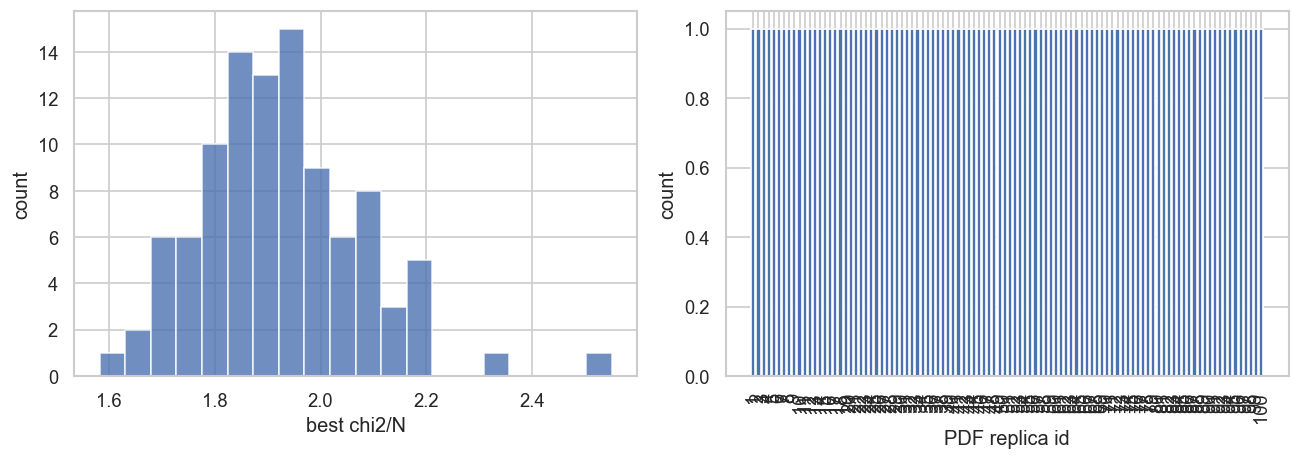

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(replica_results_df["best_chi2dN"], bins=20, alpha=0.8)
axes[0].set_xlabel("best chi2/N")
axes[0].set_ylabel("count")

pdf_counts = replica_results_df["pdf_replica_id"].dropna().astype(int).value_counts().sort_index()
axes[1].bar(pdf_counts.index.astype(str), pdf_counts.values)
axes[1].set_xlabel("PDF replica id")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


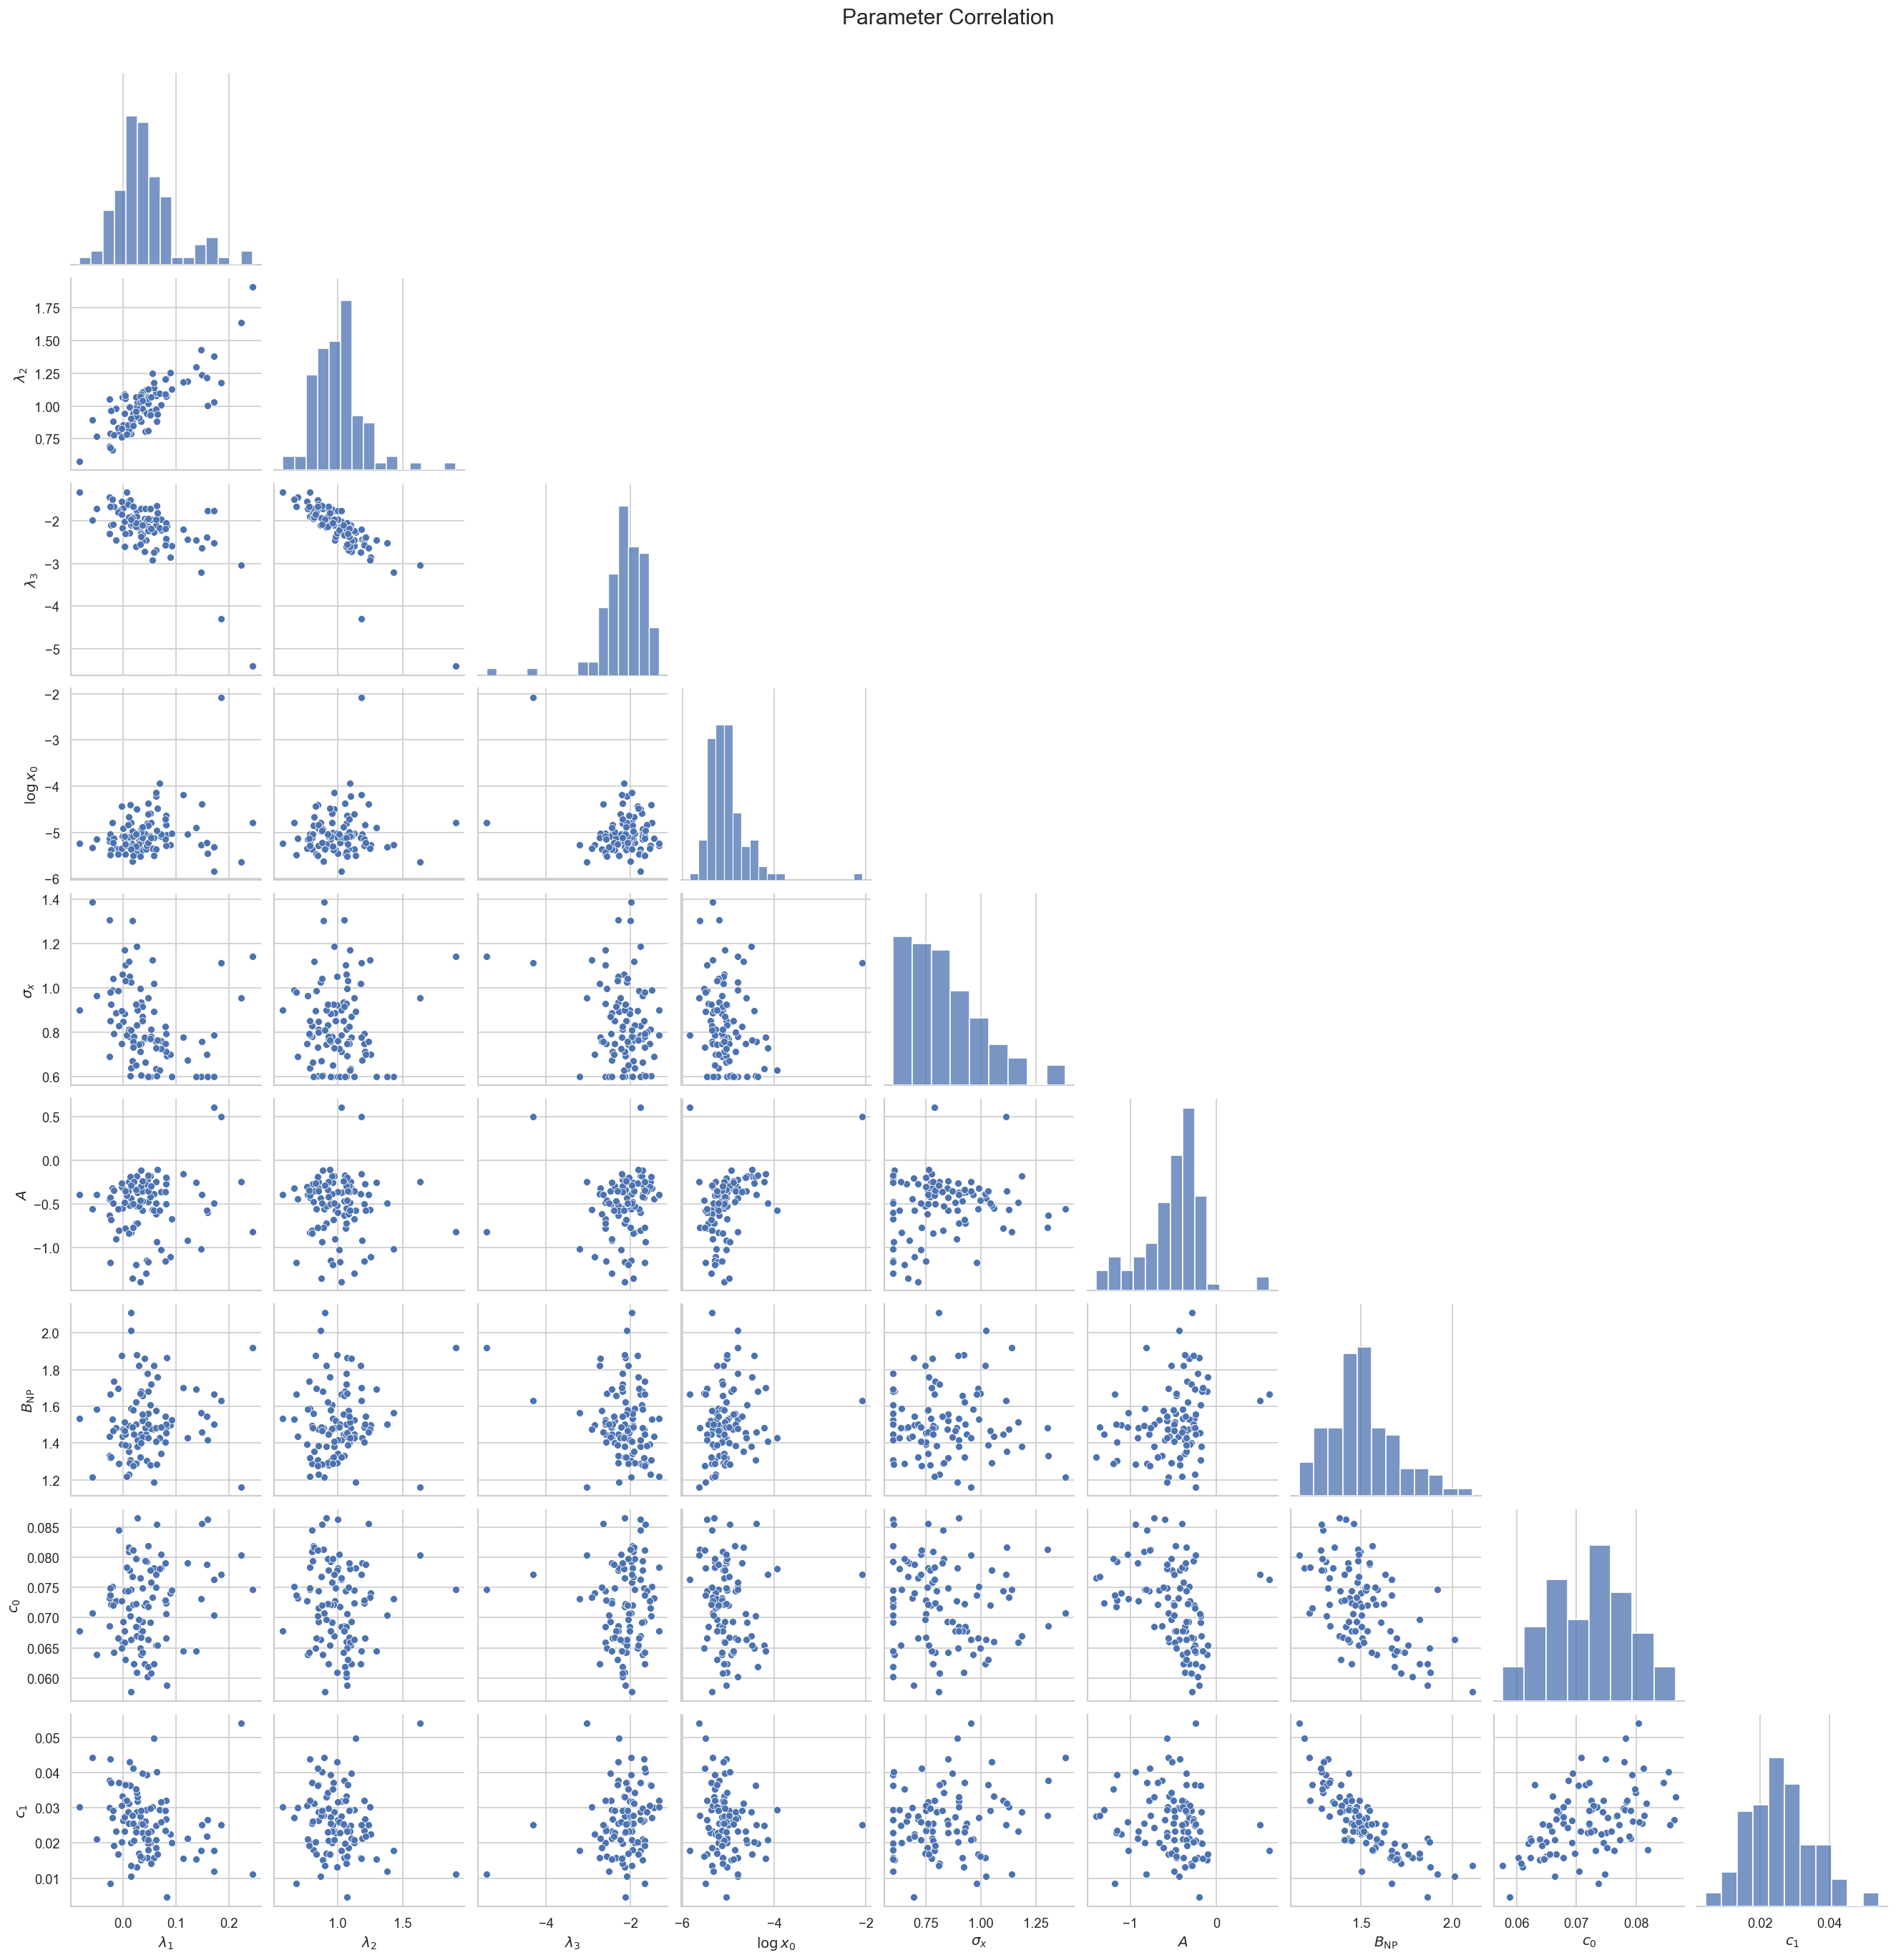

In [7]:
if pairplot_mode == "all":
    pairplot_columns = param_names
else:
    pairplot_columns = [name for i, name in enumerate(param_names) if i not in frozen_set]

plot_df = replica_results_df[pairplot_columns].copy().rename(columns=latex_param_labels)
g = sns.pairplot(plot_df, corner=True, diag_kind="hist")
g.figure.suptitle("Parameter Correlation", y=1.02, fontsize=18)
plt.show()


,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$\log x_0$,$\sigma_x$,$A$,$B_{\rm NP}$,$c_{0}$,$c_{1}$
$\lambda_{1}$,1.000,0.801,-0.628,0.230,-0.287,0.130,0.130,0.226,-0.211
$\lambda_{2}$,0.801,1.000,-0.844,0.087,0.011,-0.033,0.099,-0.050,-0.103
$\lambda_{3}$,-0.628,-0.844,1.000,-0.225,-0.226,0.085,-0.236,0.004,0.164
$\log x_0$,0.230,0.087,-0.225,1.000,-0.059,0.408,0.162,-0.079,-0.158
$\sigma_x$,-0.287,0.011,-0.226,-0.059,1.000,0.130,-0.033,-0.105,0.198
$A$,0.130,-0.033,0.085,0.408,0.130,1.000,0.256,-0.379,-0.135
$B_{\rm NP}$,0.130,0.099,-0.236,0.162,-0.033,0.256,1.000,-0.582,-0.832
$c_{0}$,0.226,-0.050,0.004,-0.079,-0.105,-0.379,-0.582,1.000,0.469
$c_{1}$,-0.211,-0.103,0.164,-0.158,0.198,-0.135,-0.832,0.469,1.000


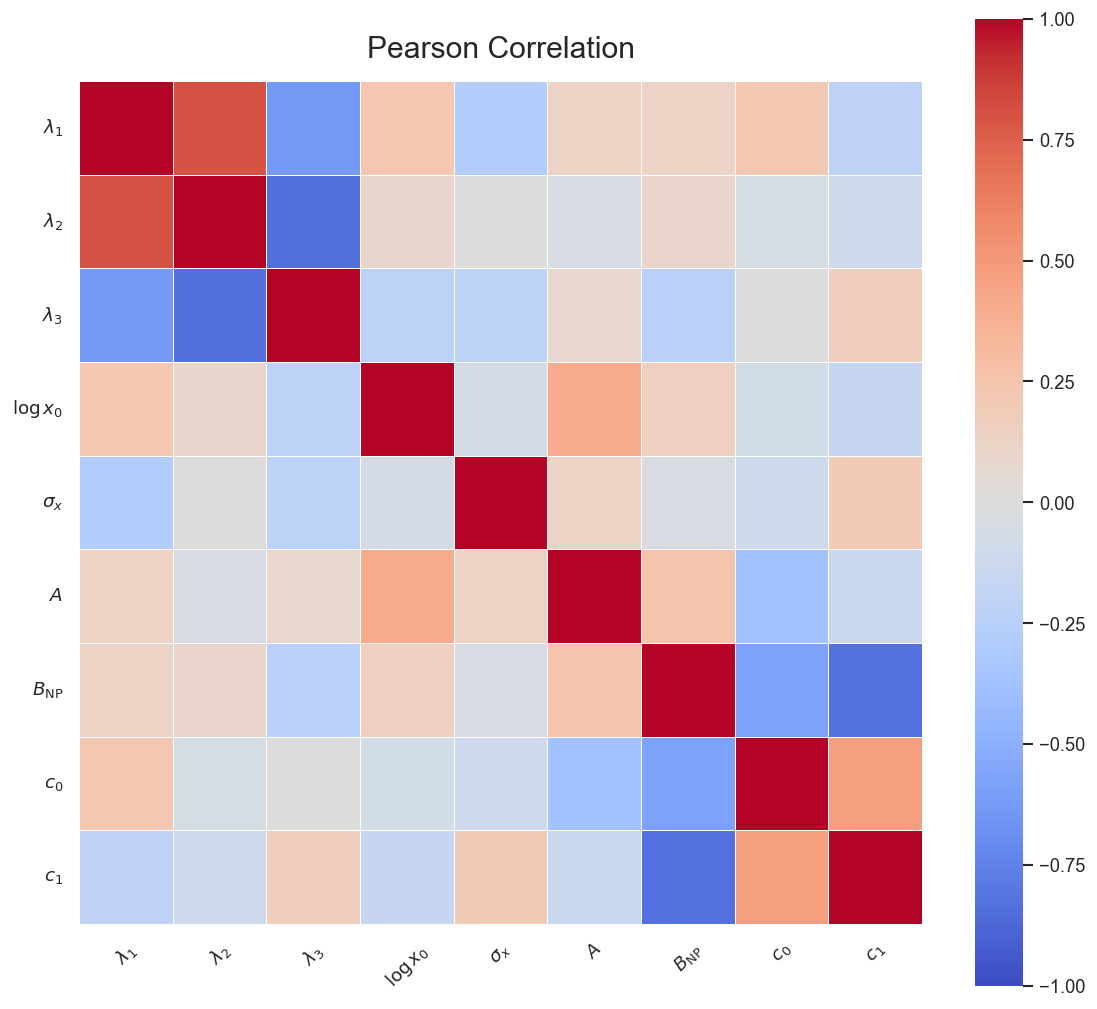

,param_a,param_b,corr,abs_corr
8,$\lambda_{2}$,$\lambda_{3}$,-0.843625,0.843625
34,$B_{\rm NP}$,$c_{1}$,-0.831509,0.831509
0,$\lambda_{1}$,$\lambda_{2}$,0.800918,0.800918
1,$\lambda_{1}$,$\lambda_{3}$,-0.627830,0.627830
33,$B_{\rm NP}$,$c_{0}$,-0.581914,0.581914
35,$c_{0}$,$c_{1}$,0.469379,0.469379
22,$\log x_0$,$A$,0.407867,0.407867
31,$A$,$c_{0}$,-0.379485,0.379485
3,$\lambda_{1}$,$\sigma_x$,-0.286561,0.286561
30,$A$,$B_{\rm NP}$,0.256456,0.256456


,quantity,value
0,n_parameters,9.000000
1,max_abs_corr_offdiag,0.843625
2,median_abs_corr_offdiag,0.163313
3,min_eigenvalue,0.022728
4,condition_number,126.236916


In [8]:
if len(pairplot_columns) < 2:
    print("Need at least two parameters to analyze correlations.")
else:
    corr_df = replica_results_df[pairplot_columns].corr()
    corr_df.index = [latex_param_labels[name] for name in corr_df.index]
    corr_df.columns = [latex_param_labels[name] for name in corr_df.columns]
    display(corr_df.round(3))

    fig_w = max(7, 0.8 * len(corr_df.columns) + 2.5)
    fig_h = max(6, 0.8 * len(corr_df.columns) + 1.5)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        corr_df,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={},
        ax=ax,
    )
    ax.set_title("Pearson Correlation", fontsize=18, pad=14)
    ax.tick_params(axis="x", labelrotation=45, labelsize=11)
    ax.tick_params(axis="y", labelrotation=0, labelsize=11)
    plt.tight_layout()
    plt.show()

    upper = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool))
    corr_pairs = (
        upper.stack()
        .rename("corr")
        .reset_index()
        .rename(columns={"level_0": "param_a", "level_1": "param_b"})
    )
    corr_pairs["abs_corr"] = corr_pairs["corr"].abs()
    corr_pairs = corr_pairs.sort_values(["abs_corr", "param_a", "param_b"], ascending=[False, True, True])
    display(corr_pairs.head(15))

    eigvals = np.linalg.eigvalsh(corr_df.to_numpy())
    corr_summary = pd.DataFrame(
        {
            "quantity": [
                "n_parameters",
                "max_abs_corr_offdiag",
                "median_abs_corr_offdiag",
                "min_eigenvalue",
                "condition_number",
            ],
            "value": [
                len(corr_df.columns),
                corr_pairs["abs_corr"].max() if not corr_pairs.empty else np.nan,
                corr_pairs["abs_corr"].median() if not corr_pairs.empty else np.nan,
                eigvals.min(),
                eigvals.max() / eigvals.min() if eigvals.min() > 0 else np.inf,
            ],
        }
    )
    display(corr_summary)
